In [1]:
import os
import torchio as tio

# pra usar cpu, descomentar linha abaixo
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import math
import nibabel as nib

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger, EarlyStopping
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers, models, Input, Model

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
import gc
import seaborn as sns

from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from PIL import Image
import tempfile
from math import ceil
import random
from tensorflow.keras import backend as K

#import wandb

2025-12-05 01:57:46.251876: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-05 01:57:46.268247: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-05 01:57:46.273881: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-05 01:57:46.287498: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
from tensorflow.keras import mixed_precision

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Evita uso excessivo de memória
        print("GPU habilitada com sucesso!")
        print("Memory Growth habilitado para a GPU")
    except RuntimeError as e:
        print(e)

mixed_precision.set_global_policy("mixed_float16")

tf.get_logger().setLevel('ERROR')

GPU habilitada com sucesso!
Memory Growth habilitado para a GPU


I0000 00:00:1764910692.137998  719236 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1764910692.140485  719236 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1764910692.140530  719236 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.


In [3]:
# FUNÇÕES

# Função para carregar imagens NIfTI, seus rótulos e cortar as imagens
def load_nifti_paths(base_dir, class_names):
    image_paths = []
    labels = []
    
    # Caminhos das subpastas
    for label in class_names:
        label_dir = os.path.join(base_dir, label)
        for fname in os.listdir(label_dir):
            img_path = os.path.join(label_dir, fname)
            image_paths.append(img_path)
            labels.append(label)

    # Codificando os rótulos
    label_encoder = LabelEncoder()

    # Inverter a ordem das classes explicitamente
    label_encoder.classes_ = np.array(class_names)

    # Codificando os rótulos (agora 'cn' será 0 e 'ad' será 1)
    labels_array = np.array(labels)
    labels_encoded = label_encoder.transform(labels_array)

    # Transformando os rótulos para one-hot encoding
    labels_one_hot = to_categorical(labels_encoded, num_classes=len(class_names))

    # Embaralhar os dados
    image_paths, labels_one_hot = shuffle(image_paths, labels_one_hot, random_state=42)

    return image_paths, labels_one_hot, label_encoder.classes_

def load_nifti_data_balanced(base_dir, class_names, target=1000):
    images = []
    labels = []
    paths = []
    
    # Caminhos das subpastas
    for label in class_names:
        print(f"carregando diretório {label}")
        label_dir = os.path.join(base_dir, label)
        count = 0

        names = os.listdir(label_dir)
        for fname in names:
            img_path = os.path.join(label_dir, fname)
            img = nib.load(img_path).get_fdata(dtype=np.float16)
            paths.append(img_path)
            images.append(img)
            labels.append(label)
            count += 1

        print(f"diretório carregado {count}")

    # Codificando os rótulos
    label_encoder = LabelEncoder()
    label_encoder.classes_ = np.array(class_names)
    labels_encoded = label_encoder.transform(labels)
    labels_one_hot = to_categorical(labels_encoded, num_classes=len(class_names))

    # Convertendo para arrays NumPy
    images = np.array(images).reshape((-1, *images[0].shape, 1))
    labels_one_hot = np.array(labels_one_hot)
    
    # Embaralhar os dados
    images, labels_one_hot, paths = shuffle(images, labels_one_hot, paths, random_state=42)
    
    return images, labels_one_hot, paths, label_encoder.classes_

def load_nifti_data_balanced_preallocated(base_dir, class_names, augment=False, target_per_class=1000):
    
    available_transforms = [
        tio.RandomBlur(p=1.0),
        tio.RandomNoise(p=1.0, std=(0, 0.05)),
        tio.RandomAnisotropy(p=1.0),
        tio.RandomElasticDeformation(p=1.0),
        tio.RandomBiasField(p=1.0),
        tio.RandomMotion(p=1.0),
        tio.RandomSpike(p=1.0),
        tio.RandomGhosting(p=1.0),
    ]

    all_paths = []
    all_labels = []
    print("Passo 1: Coletando lista de arquivos...")
    for label in class_names:
        label_dir = os.path.join(base_dir, label)
        count = 0
        names = os.listdir(label_dir)
        for fname in names:
            if count < target_per_class:
                all_paths.append(os.path.join(label_dir, fname))
                all_labels.append(label)
                count += 1
    print(f"Total de {len(all_paths)} imagens encontradas.")

    label_encoder = LabelEncoder()
    label_encoder.classes_ = np.array(class_names)
    labels_encoded = label_encoder.transform(all_labels)
    labels_one_hot = to_categorical(labels_encoded, num_classes=len(class_names)).astype(np.float16) 
    
    all_paths_shuffled, labels_one_hot_shuffled = shuffle(all_paths, labels_one_hot, random_state=42)
    
    del all_labels, labels_encoded, labels_one_hot
    gc.collect()

    if not all_paths_shuffled:
        print("Nenhuma imagem encontrada.")
        return np.array([]), np.array([]), [], label_encoder.classes_

    print("Passo 2: Determinando o shape da imagem...")
    try:
        first_img_nib = nib.load(all_paths_shuffled[0])
        img_shape = first_img_nib.get_fdata(dtype=np.float16).shape
    except Exception as e:
        print(f"Erro ao carregar a primeira imagem: {e}")
        return

    total_images = len(all_paths_shuffled)
    print(f"Shape detectado: {img_shape}. Alocando memória para {total_images} imagens...")
    
    images_final = np.empty((total_images, *img_shape, 1), dtype=np.float16)
    paths_final = [None] * total_images

    print("Passo 3: Carregando e transformando imagens...")
    for i in range(total_images):
        img_path = all_paths_shuffled[i]
        try:
            img_nib = nib.load(img_path)
            img_data_f16 = img_nib.get_fdata(dtype=np.float16)
            
            if augment:
                # Seleciona aleatoriamente de 1 a 6 transformações do pool
                num_transforms = random.randint(1, 6)
                selected_transforms = random.sample(available_transforms, num_transforms)
                transform_composer = tio.Compose(selected_transforms)

                img_data_f32 = img_data_f16.astype(np.float32)
                subject = tio.Subject(
                    mri=tio.ScalarImage(tensor=img_data_f32[np.newaxis, ...], affine=img_nib.affine)
                )
                # Aplica a composição
                transformed_data_f32 = transform_composer(subject).mri.data.numpy().squeeze(axis=0)
                img_final = transformed_data_f32.astype(np.float16)
                
                del img_data_f32, subject, transformed_data_f32, transform_composer, selected_transforms
            else:
                img_final = img_data_f16
            
            images_final[i] = img_final.reshape((*img_shape, 1))
            paths_final[i] = img_path

        except Exception as e:
            print(f"Erro em {img_path}: {e}. Inserindo array vazio.")
            images_final[i] = np.zeros((*img_shape, 1), dtype=np.float16)
            paths_final[i] = img_path
        
        if (i + 1) % 50 == 0:
            gc.collect()
            print(f"Processado {i + 1}/{total_images}...")
            
    print("Passo 4: Carregamento concluído.")
    return images_final, labels_one_hot_shuffled, paths_final, label_encoder.classes_

def nifti_data_generator_3d(images_array, labels, batch_size):
    total_n = len(images_array)
    if total_n == 0:
        raise ValueError("O Generator recebeu uma lista vazia de imagens! Verifique o carregamento dos dados.")

    while True:
        for i in range(0, total_n, batch_size):
            final = min(i + batch_size, total_n)
            batch_images = np.array(images_array[i: final])
            batch_labels = np.array(labels[i:final])
            
            yield batch_images, batch_labels

# Função para carregar imagens NIfTI, seus rótulos e cortar as imagens
def nifti_data_generator_3d_path(image_paths, labels, batch_size, size):
    cache_size = batch_size*size
    while True:
        for i in range(0, len(image_paths), cache_size):
            final = min(i + cache_size, len(image_paths))
            batch_paths = image_paths[i:final]
            batch_labels = labels[i:final]
            images = []

            for path in batch_paths:
                # Carregar a imagem NIfTI e garantir o formato correto
                img = nib.load(path).get_fdata(dtype=np.float16) 
                img = img[..., np.newaxis] 
                images.append(img)
            
            # Converter lista para array NumPy e garantir o shape correto
            images = np.array(images) 
            batch_labels = np.array(batch_labels)

            # Liberar memória
            gc.collect()
            
            yield images, batch_labels

# realizar predições e armazenar em um vetor
def get_predictions(images, labels, batch_size, best_model):
    pred = []

    for i in range(0, len(images), batch_size):
        final = min(i + batch_size, len(images))
        
        # Fazendo predição para o lote atual
        batch_pred = best_model.predict(images[i:final])
        pred.append(batch_pred)

    # Concatenando as predições e os rótulos verdadeiros
    pred = np.concatenate(pred)

    # Convertendo as predições para rótulos (a classe com maior probabilidade)
    true_labels = np.argmax(labels, axis=1)
    pred_labels = np.argmax(pred, axis=1)
    return pred_labels, true_labels, pred

def plot_training_history(history, dir, title='training_history.png'):
    plt.figure(figsize=(12, 4))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Graphic')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['categorical_accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_categorical_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Graphic')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.savefig(os.path.join(dir, title))

    plt.show()

def plot_confusion_matrix(y_true, y_pred, dir, subset, class_names):
    cm = confusion_matrix(y_true, y_pred)

    # Plotando a matriz de confusão
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names,  annot_kws={"size": 14})
    plt.xlabel('Previsões')
    plt.ylabel('Valores Reais')
    plt.title(f'Matriz de Confusão - {subset}')
    plt.savefig(f'{dir}/{subset}_confusion_matrix.png')
    plt.show()

def get_classification_report(y_true, y_pred, dir, subset):
    report = classification_report(y_true, y_pred)
    print(report)

    # Escrevendo o relatório em um arquivo .txt
    with open(os.path.join(dir, f"{subset}_classification_report.txt"), "w") as file:
        file.write(report)

# Função para carregar uma imagem NIfTI e extrair uma fatia específica do eixo Z
def load_nifti_image_pdf(file_path):
    img = nib.load(file_path) 
    data = img.get_fdata(dtype=np.float16)  
    slice_2d = data[2, :, :]
    return slice_2d

# Função para criar o PDF
def create_pdf(y_paths, y_images, y_true_labels, y_pred_labels, y_pred, output_pdf_path, class_names):
    c = canvas.Canvas(output_pdf_path, pagesize=letter)
    width, height = letter  # Dimensões da página no PDF

    #for image, name in zip(y_images, y_paths):
    for i in range(0, len(y_images)):
        true = ''
        pred = ''
        # Carregar a imagem NIfTI e obter a fatia 2D no eixo Z
        # nifti_image = load_nifti_image_pdf(item)
        nifti_image = y_images[i][:, :, 88, 0]

        # Converter a fatia 2D para uma imagem 8-bit (grayscale) para visualização
        img = Image.fromarray(np.uint8(nifti_image / np.max(nifti_image) * 255))  # Normalizar e converter
        img = img.convert("RGB")  # Garantir que a imagem tenha 3 canais (RGB)

        # Redimensionar a imagem para se ajustar ao tamanho da página
        img_width, img_height = img.size
        aspect_ratio = img_height / float(img_width)
        new_width = width * 0.2  # Definir largura como 80% da largura da página
        new_height = new_width * aspect_ratio
        img = img.resize((int(new_width), int(new_height)))

        # Criar um arquivo temporário para salvar a imagem
        with tempfile.NamedTemporaryFile(delete=False, suffix=".png") as temp_file:
            temp_file_path = temp_file.name
            img.save(temp_file_path)

        # configurar para printar as 7 fatias em uma página inteira, com as informações de label predito e esperado

        # Colocar a imagem no PDF usando o caminho temporário
        if i % 12 < 4:
            x = 80
        elif i % 12 < 8:
            x = width - 2.35*new_width - 80
        else:
            x = width - new_width - 80

        y = height - (new_height + 80)*((i%4)+1)

        c.drawImage(temp_file_path, x, y, width=new_width, height=new_height)

        # Escrever os rótulos
        true_label = y_true_labels[i]
        pred_label = y_pred_labels[i]

        #ver como transformar os labels de maneira inteligente
        true = class_names[true_label]
        pred = class_names[pred_label]

        # Definir a cor para os rótulos
        if true_label == pred_label:
            pred_color = (0, 1, 0)  # Verde
        else:
            pred_color = (1, 0, 0)  # Vermelho
        
        #Nome paciente (em preto)
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(0, 0, 0)  # Preto
        c.drawString(x+24, y+new_height+50, f"{os.path.basename(y_paths[i])}")

        # Rótulo esperado (em preto)
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(0, 0, 0)  # Preto
        c.drawString(x+26, y+new_height+35, f"Expected: {true}")

        # Rótulo predito
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(*pred_color)  # Verde ou Vermelho
        c.drawString(x+26, y+new_height+20, f"Predicted: {pred}")

        # Rótulo predito
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(*pred_color)  # Verde ou Vermelho
        c.drawString(x+26, y+new_height+5, f"Prob: {max(y_pred[i])*100:.2f}%")

        # Avançar para a próxima imagem
        i += 1
        
        # Adicionar uma nova página no PDF a cada 2 imagens (se necessário)
        if i % 12 == 0:
            c.showPage()

    # Salvar o PDF
    c.save()

def plot_custom_confusion_matrix(cm, y_labels, x_labels, dir, subset):
    plt.figure(figsize=(10, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=x_labels, yticklabels=y_labels, 
                annot_kws={"size": 14})
    plt.xlabel('Previsões')
    plt.ylabel('Valores Reais')
    plt.title(f'Matriz de Confusão - {subset}')
    plt.savefig(f'{dir}/{subset}_custom_confusion_matrix.png', bbox_inches='tight')
    plt.show()

def create_model_3d(input_shape, n_classes):
    inputs = Input(shape=input_shape)  # (D, H, W, C)

    # Camada 1
    x = layers.Conv3D(4, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Camada 2
    x = layers.Conv3D(8, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Camada 3
    x = layers.Conv3D(16, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # # Camada 4
    # x = layers.Conv3D(32, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    # x = layers.BatchNormalization()(x)
    # x = layers.LeakyReLU(negative_slope=0.3)(x)
    # # x = layers.MaxPooling3D(pool_size=(2, 2, 2), padding='same')(x)
    # x = layers.Dropout(0.3)(x)

    # Flatten e densas
    x = layers.Flatten()(x)

    x = layers.Dense(16, kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)

    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model

In [4]:
# Definindo caminhos
dir_base = "/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn"

train_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/train'
val_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/validation'
test_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/test'

fine_tunning_train_dir = f'{dir_base}/OASIS/OASIS_1_FSL_NORMALIZED/train'
fine_tunning_val_dir = f'{dir_base}/OASIS/OASIS_1_FSL_NORMALIZED/validation'

oasis_train = f'{dir_base}/OASIS/OASIS_1_FSL_NORMALIZED/train'
oasis_validation = f'{dir_base}/OASIS/OASIS_1_FSL_NORMALIZED/validation'

results_dir_base = f'{dir_base}/ADNI/ADNI_NORMALIZED/results/ruidos_pre_treino'
os.makedirs(results_dir_base, exist_ok=True)

transformations = ['noise']

In [5]:
n = len(os.listdir(results_dir_base))

if (n > 0):
    if (len(os.listdir(os.path.join(results_dir_base, f'test_{n}'))) < 3): 
        for item in os.listdir(os.path.join(results_dir_base, f"test_{n}")):
            os.remove(os.path.join(results_dir_base,  f"test_{n}", item))
        os.removedirs(os.path.join(results_dir_base, f'test_{n}'))
        n -= 1

folder_name = f"test_{str(n+1)}"
results_dir = os.path.join(results_dir_base, folder_name)
os.makedirs(results_dir, exist_ok=True)
print(f"pasta {folder_name} criada")

pasta test_5 criada


# Pré-treino

In [6]:
# Nome das classes
# adni_class_names = ['cn', 'emci', 'mci', 'lmci', 'ad']
adni_class_names = ['cn', 'mci', 'ad']
# oasis_class_names = ['0.0', '0.5', '1.0', '2.0']
oasis_class_names = ['0.0', '0.5', '1.0']

n_adni_classes = len(adni_class_names)
n_oasis_classes = len(oasis_class_names)

train_images, train_labels, train_paths, class_labels = load_nifti_data_balanced_preallocated(
    train_dir, 
    adni_class_names, 
    augment=True
)

print(f"N treino: {len(train_paths)}")

val_images, val_labels, val_paths, _ = load_nifti_data_balanced_preallocated(
    val_dir, 
    adni_class_names, 
    augment=False
)

print(f"N validation: {len(val_paths)}")

Passo 1: Coletando lista de arquivos...
Total de 1599 imagens encontradas.
Passo 2: Determinando o shape da imagem...
Shape detectado: (156, 195, 160). Alocando memória para 1599 imagens...
Passo 3: Carregando e transformando imagens...
Processado 50/1599...
Processado 100/1599...
Processado 150/1599...
Processado 200/1599...
Processado 250/1599...
Processado 300/1599...
Processado 350/1599...
Processado 400/1599...
Processado 450/1599...
Processado 500/1599...
Processado 550/1599...
Processado 600/1599...
Processado 650/1599...
Processado 700/1599...
Processado 750/1599...
Processado 800/1599...
Processado 850/1599...
Processado 900/1599...
Processado 950/1599...
Processado 1000/1599...
Processado 1050/1599...
Processado 1100/1599...
Processado 1150/1599...
Processado 1200/1599...
Processado 1250/1599...
Processado 1300/1599...
Processado 1350/1599...
Processado 1400/1599...
Processado 1450/1599...
Processado 1500/1599...
Processado 1550/1599...
Passo 4: Carregamento concluído.
N trei

In [7]:
def generate_axial_pdf_reports_no_prediction(images, true_labels_onehot, class_names, output_dir, max_samples=None):
    """
    Gera um PDF SEPARADO para cada volume 3D, contendo todas as fatias axiais.
    
    Args:
        model: Modelo treinado.
        images: Array numpy (N, D, H, W, C).
        true_labels_onehot: Labels reais (N, n_classes).
        class_names: Lista de nomes das classes.
        output_dir: Diretório onde os PDFs serão salvos.
        max_samples: Limite de amostras.
    """
    
    # 1. Setup inicial
    true_indices = np.argmax(true_labels_onehot, axis=1)
    
    n_samples = len(images)
    if max_samples is not None and max_samples < n_samples:
        n_samples = max_samples
        print(f"Limitando relatórios a {n_samples} amostras.")

    # 2. Cria o diretório de saída
    os.makedirs(output_dir, exist_ok=True)
    print(f"Gerando {n_samples} relatórios PDF em: {output_dir}")

    # 3. Loop Externo (Um PDF por volume)
    for i in range(0,n_samples):
        vol = images[i]
        true_index = true_indices[i]
        true_label = class_names[true_index]
    
        # Nome descritivo para o PDF (preenchimento com zeros para ordenação)
        pdf_filename = f"Amostra_{i:04d}_Real_{true_label}_.pdf"
        pdf_path_full = os.path.join(output_dir, pdf_filename)
        
        try:
            # 6. Abre o arquivo PDF para o volume atual
            with PdfPages(pdf_path_full) as pdf:
                
                # Assumindo shape (D, H, W, C), o eixo Axial é o índice 2 (W)
                num_axial_slices = vol.shape[2] 
                
                # 7. Loop Interno (Uma página por fatia axial)
                for k in range(num_axial_slices):
                    # Extrai a fatia axial 'k'
                    img_slice = vol[:, :, k, 0] 

                    fig, ax = plt.subplots(figsize=(6, 6))
                    
                    # Usa .T (Transposto) e origin='lower' para orientação radiológica padrão
                    ax.imshow(img_slice.T, cmap='gray', origin='lower')
                    ax.axis('off')
                    
                    # Título para a página
                    title_text = (f"Amostra {i} [Fatia Axial {k+1}/{num_axial_slices}]]\n"
                                  f"Real: {true_label}")
                    
                    ax.set_title(title_text, fontsize=10)
                    
                    # Salva a página atual no PDF
                    pdf.savefig(fig)
                    # Fecha a figura para liberar memória (CRÍTICO)
                    plt.close(fig) 

        except Exception as e:
            print(f"Erro ao gerar PDF {pdf_path_full}: {e}")
            plt.close('all') # Fecha todas as figuras em caso de falha

        # Log no loop externo
        if (i + 20) % 100 == 0: # Log mais frequente
            print(f"Processado {i + 10}/{n_samples} volumes (PDFs gerados)...")

    print(f"Geração de {n_samples} relatórios PDF concluída.")

# Crie uma pasta específica para esta saída massiva
pdf_reports_dir = os.path.join(results_dir, "relatorios_10_pessoas")

# Chame a nova função
generate_axial_pdf_reports_no_prediction(
    images=train_images,
    true_labels_onehot=train_labels,
    class_names=adni_class_names,
    output_dir=pdf_reports_dir,
    max_samples=20
)

Limitando relatórios a 20 amostras.
Gerando 20 relatórios PDF em: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/ruidos_pre_treino/test_5/relatorios_10_pessoas
Geração de 20 relatórios PDF concluída.


In [8]:
# ==============================================================================
# CONFIGURAÇÃO DA FASE DE TREINAMENTO
# ==============================================================================
# 1 = Pré-treinamento
# 2 = Fine-tuning
fase_atual = 1

# Defina os caminhos base para salvar/carregar
PATH_PRETREINADO = os.path.join(results_dir, "modelo_pretrained.keras")
PATH_FINETUNED = os.path.join(results_dir, "modelo_final.keras")

In [9]:
print("--- INICIANDO FASE 1: PRÉ-TREINAMENTO ---")

# Cria modelo do zero
model = create_model_3d(train_images[0].shape, n_adni_classes)

# Compilação padrão
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
                loss='categorical_crossentropy', 
                metrics=['categorical_accuracy'])

model.summary()

--- INICIANDO FASE 1: PRÉ-TREINAMENTO ---


I0000 00:00:1764913163.447986  719236 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1764913163.448061  719236 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1764913163.448081  719236 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1764913163.878050  719236 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1764913163.878119  719236 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-12-05

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 156, 195, 160,  │             0 │
│                                 │ 1)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d (Conv3D)                 │ (None, 156, 195, 160,  │           112 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 156, 195, 160,  │            16 │
│ (BatchNormalization)            │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 156, 195, 160,  │             0 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d               │ (None, 52, 65, 54, 4)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 52, 65, 54, 4)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 52, 65, 54, 8)  │           872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 52, 65, 54, 8)  │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 52, 65, 54, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_1             │ (None, 18, 22, 18, 8)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18, 22, 18, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 18, 22, 18, 16) │         3,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 18, 22, 18, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 18, 22, 18, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_2             │ (None, 6, 8, 6, 16)    │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 8, 6, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        73,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             

 Total params: 78,427 (306.36 KB)

 Trainable params: 78,339 (306.01 KB)

 Non-trainable params: 88 (352.00 B)

In [10]:
batch_size = 64

steps_per_epoch = math.ceil(len(train_images) / batch_size)
validation_steps = math.ceil(len(val_images) / batch_size)

train_generator = nifti_data_generator_3d(train_images, train_labels, batch_size)
val_generator = nifti_data_generator_3d(val_images, val_labels, batch_size)

# Callbacks
csv_filename = 'log_treino_fase1.csv'
checkpoint_path = PATH_PRETREINADO

callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=30, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1),
    CSVLogger(os.path.join(results_dir, csv_filename)),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_categorical_accuracy', save_best_only=True, mode='max')
]

In [11]:
epochs = 300

print(f"Iniciando treinamento FASE {fase_atual} por {epochs} épocas...")

history_pretrained = model.fit(
    train_generator,
    epochs=epochs,
    verbose=1,
    validation_data=val_generator,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks_list
)

Iniciando treinamento FASE 1 por 300 épocas...
Epoch 1/300


I0000 00:00:1764913169.296797  949869 service.cc:146] XLA service 0x7fc7440070c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764913169.296850  949869 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2025-12-05 02:39:29.621973: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-05 02:39:30.330430: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
2025-12-05 02:39:35.495049: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.34GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-12-05 02:39:35.495144: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Al

24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 727ms/step - categorical_accuracy: 0.3673 - loss: 1.7817

2025-12-05 02:40:42.379682: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng0{} for conv (f16[4,1,3,3,3]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[63,1,156,195,160]{4,3,2,1,0}, f16[63,4,156,195,160]{4,3,2,1,0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBackwardFilter", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2025-12-05 02:40:46.840604: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 5.463125734s
Trying algorithm eng0{} for conv (f16[4,1,3,3,3]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[63,1,156,195,160]{4,3,2,1,0}, f16[63,4,156,195,160]{4,3,2,1,0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBackwardFilter", backend

25/25 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - categorical_accuracy: 0.3533 - loss: 1.7554 - val_categorical_accuracy: 0.3982 - val_loss: 1.5824 - learning_rate: 5.0000e-04
Epoch 2/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 834ms/step - categorical_accuracy: 0.3596 - loss: 1.6761 - val_categorical_accuracy: 0.4732 - val_loss: 1.5568 - learning_rate: 5.0000e-04
Epoch 3/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 841ms/step - categorical_accuracy: 0.3840 - loss: 1.6160 - val_categorical_accuracy: 0.4308 - val_loss: 1.5198 - learning_rate: 5.0000e-04
Epoch 4/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 844ms/step - categorical_accuracy: 0.4078 - loss: 1.5610 - val_categorical_accuracy: 0.5023 - val_loss: 1.4846 - learning_rate: 5.0000e-04
Epoch 5/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 833ms/step - categorical_accuracy: 0.4234 - loss: 1.5068 - val_categorical_accuracy: 0.3575 - val_loss: 1.4561 - learning_rate: 5.0000e-04
Epoch 6/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 839ms/step - categorical_accuracy: 0.4371 - loss: 1.4645 - va

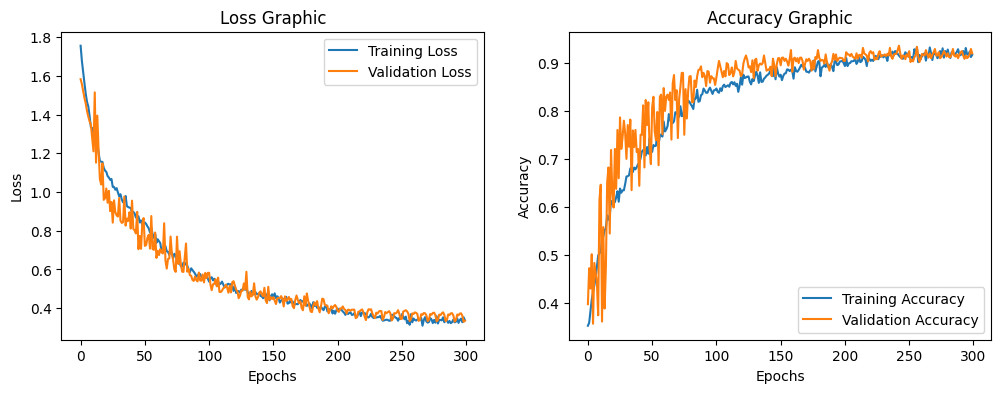

In [12]:
# Plotando o histórico de treinamento após o treinamento
os.makedirs(f"{results_dir}/pretrained", exist_ok=True)
plot_training_history(history_pretrained, f"{results_dir}/pretrained", 'pre_training_adni_training_history.png')

### PREDIÇÃO VALIDAÇÃO PRE TREINO

2025-12-05 04:25:58.864712: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.66GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-12-05 04:25:58.864798: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.66GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-12-05 04:25:58.864846: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.66GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-12-05 04:25:58.864891: W external/local_tsl/tsl/framework/bfc_

2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 209ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 205ms/step
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step

2025-12-05 04:26:18.112543: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %reduce-window.127 = f32[26,18,22,18,8]{4,3,2,1,0} reduce-window(f32[26,52,65,54,8]{4,3,2,1,0} %broadcast.115, f32[] %constant.116), window={size=1x3x3x3x1 stride=1x3x3x3x1 pad=0_0x1_1x0_1x0_0x0_0}, to_apply=%region_1.123, metadata={op_type="AvgPool3D" op_name="functional_1/average_pooling3d_1_2/AvgPool3D"}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2025-12-05 04:26:21.054338: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 3.941913905s
Constant folding an instruct

2/2 ━━━━━━━━━━━━━━━━━━━━ 40s 40s/step
              precision    recall  f1-score   support

           0       0.91      0.92      0.91       137
           1       0.97      0.90      0.93       153
           2       0.88      0.94      0.91       152

    accuracy                           0.92       442
   macro avg       0.92      0.92      0.92       442
weighted avg       0.92      0.92      0.92       442



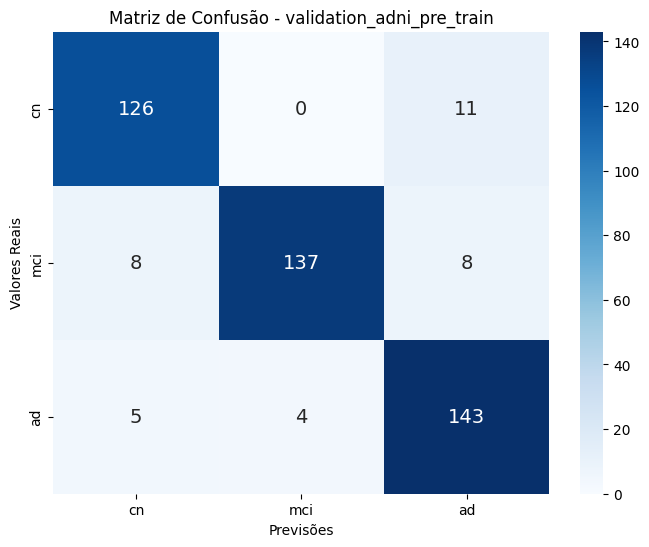

In [13]:
# Realizar predições para dados do conjunto validação
val_pred_labels, val_true_labels, val_pred = get_predictions(val_images, val_labels, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
get_classification_report(val_true_labels, val_pred_labels, f"{results_dir}/pretrained", 'validation_adni_pre_train')

# Obter matriz de confusão
plot_confusion_matrix(val_true_labels, val_pred_labels, f"{results_dir}/pretrained", 'validation_adni_pre_train', adni_class_names)

# Criar pdf com predições
val_pdf_path = os.path.join(f"{results_dir}/pretrained", "validation_adni_predictions_pre_train.pdf")
create_pdf(val_paths, val_images, val_true_labels, val_pred_labels, val_pred, val_pdf_path, adni_class_names)

### PREDIÇÃO TESTE PRE TREINO

Passo 1: Coletando lista de arquivos...
Total de 227 imagens encontradas.
Passo 2: Determinando o shape da imagem...
Shape detectado: (156, 195, 160). Alocando memória para 227 imagens...
Passo 3: Carregando e transformando imagens...
Processado 50/227...
Processado 100/227...
Processado 150/227...
Processado 200/227...
Passo 4: Carregamento concluído.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 223ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 5s/step  
              precision    recall  f1-score   support

           0       0.89      0.96      0.92        73
           1       0.99      0.87      0.92        77
           2       0.94      0.97      0.96        77

    accuracy                           0.93       227
   macro avg       0.94      0.93      0.93       227
weighted avg       0.94      0.93      0.93       227



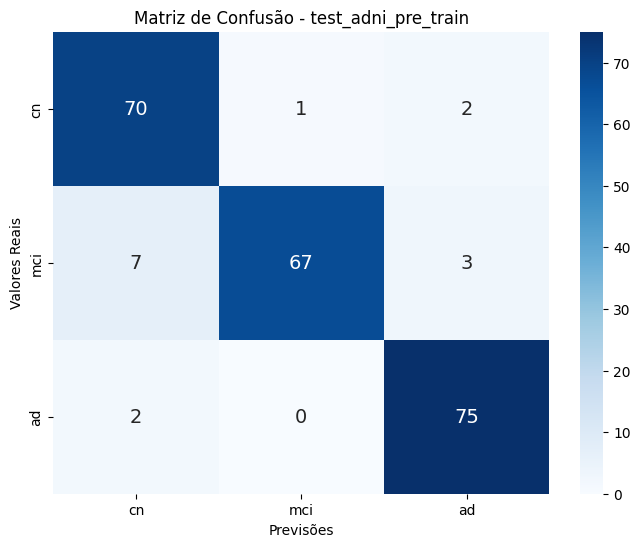

/tmp/ipykernel_719236/1130439845.py:289: RuntimeWarning: invalid value encountered in divide
  img = Image.fromarray(np.uint8(nifti_image / np.max(nifti_image) * 255))  # Normalizar e converter
/tmp/ipykernel_719236/1130439845.py:289: RuntimeWarning: invalid value encountered in cast
  img = Image.fromarray(np.uint8(nifti_image / np.max(nifti_image) * 255))  # Normalizar e converter


In [14]:
test_images, test_labels, test_paths, _ = load_nifti_data_balanced_preallocated(test_dir, adni_class_names)

# Realizar predições para dados do conjunto validação
test_pred_labels, test_true_labels, test_pred = get_predictions(test_images, test_labels, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
get_classification_report(test_true_labels, test_pred_labels, f"{results_dir}/pretrained", 'test_adni_pre_train')

# Obter matriz de confusão
plot_confusion_matrix(test_true_labels, test_pred_labels, f"{results_dir}/pretrained", 'test_adni_pre_train', adni_class_names)

# Criar pdf com predições
test_pdf_path = os.path.join(f"{results_dir}/pretrained", "test_adni_predictions_pre_train.pdf")
create_pdf(test_paths, test_images, test_true_labels, test_pred_labels, test_pred, test_pdf_path, adni_class_names)

### PREDIÇÃO OASIS PRE TREINO

Passo 1: Coletando lista de arquivos...
Total de 69 imagens encontradas.
Passo 2: Determinando o shape da imagem...
Shape detectado: (156, 195, 160). Alocando memória para 69 imagens...
Passo 3: Carregando e transformando imagens...
Processado 50/69...
Passo 4: Carregamento concluído.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step


2025-12-05 04:28:19.433855: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng10{k2=6,k13=0,k14=2,k18=0,k23=0} for conv (f16[5,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[5,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2025-12-05 04:28:19.756559: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.322813755s
Trying algorithm eng10{k2=6,k13=0,k14=2,k18=0,k23=0} for conv (f16[5,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[5,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        40
           1       0.33      1.00      0.50        23
           2       0.00      0.00      0.00         6

    accuracy                           0.33        69
   macro avg       0.11      0.33      0.17        69
weighted avg       0.11      0.33      0.17        69



/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no

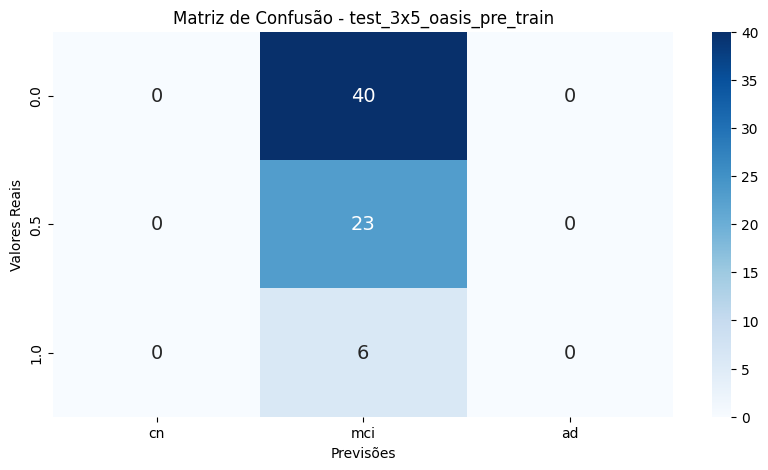

In [15]:
oasis_images, oasis_labels, oasis_paths, _ = load_nifti_data_balanced_preallocated(oasis_validation, oasis_class_names)

# Realizar predições para dados do conjunto validação
oasis_pred_labels, oasis_true_labels, oasis_pred = get_predictions(oasis_images, oasis_labels, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
get_classification_report(oasis_true_labels, oasis_pred_labels, f"{results_dir}/pretrained", 'test_oasis_pre_train')

# Obter matriz de confusão
cm_adjusted = confusion_matrix(oasis_true_labels, oasis_pred_labels)
plot_custom_confusion_matrix(cm_adjusted, oasis_class_names, adni_class_names, f"{results_dir}/pretrained", 'test_3x5_oasis_pre_train')

# gathered_oasis_pred = []

# for i in range(len(oasis_pred_labels)):
#     if oasis_pred_labels[i] == 0:
#         gathered_oasis_pred.append(0)
#     elif oasis_pred_labels[i] < 4 and oasis_pred_labels[i] > 0:
#         gathered_oasis_pred.append(1)
#     elif oasis_pred_labels[i] == 4:
#         gathered_oasis_pred.append(2)

# all_possible_numeric_labels = [0.0, 0.5, 1.0, 2.0, 3.0]

# cm_3x3_adjusted = confusion_matrix(oasis_true_labels, gathered_oasis_pred)

# Chame a nova função para plotar a matriz ajustada (3x5)
# plot_custom_confusion_matrix(cm_3x3_adjusted, oasis_class_names, oasis_class_names, f"{results_dir}/pretrained", 'test_3x3_oasis_pre_train')

# Criar pdf com predições
oasis_pdf_path = os.path.join(f"{results_dir}/pretrained", "test_oasis_predictions_pre_train.pdf")
# create_pdf(oasis_paths, oasis_images, oasis_true_labels, gathered_oasis_pred, oasis_pred, oasis_pdf_path, oasis_class_names)
create_pdf(oasis_paths, oasis_images, oasis_true_labels, oasis_true_labels, oasis_pred, oasis_pdf_path, oasis_class_names)

In [16]:
print(oasis_labels)

[[1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]]


# Transfer learning

In [17]:
# LIMPAR DADOS
del train_images
del train_labels
del train_paths
del val_images
del val_labels
del val_paths
gc.collect()

0

In [18]:
train_images_fine_tunning, train_labels_fine_tunning, train_paths_fine_tunning, class_labels_fine_tunning = load_nifti_data_balanced_preallocated(
    fine_tunning_train_dir, 
    oasis_class_names, 
    augment=True
)

print(f"N treino: {len(train_images_fine_tunning)}")

val_images_fine_tunning, val_labels_fine_tunning, val_paths_fine_tunning, _ = load_nifti_data_balanced_preallocated(
    fine_tunning_val_dir, 
    oasis_class_names, 
    augment=True
)

print(f"N validation: {len(val_paths_fine_tunning)}")

Passo 1: Coletando lista de arquivos...
Total de 164 imagens encontradas.
Passo 2: Determinando o shape da imagem...
Shape detectado: (156, 195, 160). Alocando memória para 164 imagens...
Passo 3: Carregando e transformando imagens...
Processado 50/164...
Processado 100/164...
Processado 150/164...
Passo 4: Carregamento concluído.
N treino: 164
Passo 1: Coletando lista de arquivos...
Total de 69 imagens encontradas.
Passo 2: Determinando o shape da imagem...
Shape detectado: (156, 195, 160). Alocando memória para 69 imagens...
Passo 3: Carregando e transformando imagens...
Processado 50/69...
Passo 4: Carregamento concluído.
N validation: 69


In [19]:
print(val_labels_fine_tunning)

[[1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]]


In [20]:
fase_atual = 1
print("--- INICIANDO FASE 2: FINE-TUNING ---")

# CARREGA O MODELO DA FASE 1
if not os.path.exists(PATH_PRETREINADO):
    raise FileNotFoundError(f"Modelo pré-treinado não encontrado em {PATH_PRETREINADO}. Rode a Fase 1 primeiro.")

print(f"Carregando pesos de: {PATH_PRETREINADO}")
base_model = load_model(PATH_PRETREINADO)

# --- CONGELAMENTO E ADAPTAÇÃO ---
# 1. Remover a camada de classificação antiga e adicionar uma nova (ADnetEx)
# Pega a saída da camada anterior à última
x = base_model.layers[-2].output 

# Adiciona nova camada de classificação inicializada aleatoriamente
predictions = layers.Dense(n_oasis_classes, activation='softmax', name='new_output')(x)

model = models.Model(inputs=base_model.input, outputs=predictions)

# 2. Congelar camadas iniciais (Freezing)
# Vamos congelar as primeiras 7 camadas (aprox. o primeiro bloco convolucional)
for layer in model.layers[:7]:
    layer.trainable = False
    print(f"Camada congelada: {layer.name}")

# 3. Recompilar
# Usar mesmo learning_rate do pre_treino
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
                loss='categorical_crossentropy', 
                metrics=['categorical_accuracy'])

model.summary()

--- INICIANDO FASE 2: FINE-TUNING ---
Carregando pesos de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/ruidos_pre_treino/test_5/modelo_pretrained.keras
Camada congelada: input_layer
Camada congelada: conv3d
Camada congelada: batch_normalization
Camada congelada: leaky_re_lu
Camada congelada: average_pooling3d
Camada congelada: dropout
Camada congelada: conv3d_1


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 156, 195, 160,  │             0 │
│                                 │ 1)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d (Conv3D)                 │ (None, 156, 195, 160,  │           112 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 156, 195, 160,  │            16 │
│ (BatchNormalization)            │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 156, 195, 160,  │             0 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d               │ (None, 52, 65, 54, 4)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 52, 65, 54, 4)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 52, 65, 54, 8)  │           872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 52, 65, 54, 8)  │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 52, 65, 54, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_1             │ (None, 18, 22, 18, 8)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18, 22, 18, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 18, 22, 18, 16) │         3,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 18, 22, 18, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 18, 22, 18, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_2             │ (None, 6, 8, 6, 16)    │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 8, 6, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        73,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             

 Total params: 78,427 (306.36 KB)

 Trainable params: 77,347 (302.14 KB)

 Non-trainable params: 1,080 (4.22 KB)

In [21]:
batch_size = 64

steps_per_epoch = math.ceil(len(train_images_fine_tunning) / batch_size)
validation_steps = math.ceil(len(val_images_fine_tunning) / batch_size)

train_generator_fine_tunning = nifti_data_generator_3d(train_images_fine_tunning, train_labels_fine_tunning, batch_size)
val_generator_fine_tunning = nifti_data_generator_3d(val_images_fine_tunning, val_labels_fine_tunning, batch_size)

# Callbacks
csv_filename = 'log_treino_fase2.csv'
checkpoint_path = PATH_FINETUNED

callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=30, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=30, verbose=1),
    CSVLogger(os.path.join(results_dir, csv_filename)),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_categorical_accuracy', save_best_only=True, mode='max')
]

In [22]:
epochs = 200 # Fine-tuning geralmente requer menos épocas

print(f"Iniciando treinamento FASE {fase_atual} por {epochs} épocas...")

history_fine_tunning = model.fit(
    train_generator_fine_tunning,
    epochs=epochs,
    verbose=1,
    validation_data=val_generator_fine_tunning,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks_list
)

Iniciando treinamento FASE 1 por 200 épocas...
Epoch 1/200
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - categorical_accuracy: 0.3984 - loss: 1.3693

2025-12-05 04:33:27.690863: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng10{k2=2,k13=0,k14=3,k18=0,k23=0} for conv (f16[36,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[36,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2025-12-05 04:33:28.249822: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.559061823s
Trying algorithm eng10{k2=2,k13=0,k14=3,k18=0,k23=0} for conv (f16[36,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[36,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, 

3/3 ━━━━━━━━━━━━━━━━━━━━ 65s 29s/step - categorical_accuracy: 0.4268 - loss: 1.3233 - val_categorical_accuracy: 0.2464 - val_loss: 1.5822 - learning_rate: 5.0000e-04
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 560ms/step - categorical_accuracy: 0.5488 - loss: 1.0781 - val_categorical_accuracy: 0.3333 - val_loss: 1.5540 - learning_rate: 5.0000e-04
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 592ms/step - categorical_accuracy: 0.6220 - loss: 0.9642 - val_categorical_accuracy: 0.3478 - val_loss: 1.5696 - learning_rate: 5.0000e-04
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 563ms/step - categorical_accuracy: 0.6341 - loss: 0.8504 - val_categorical_accuracy: 0.3623 - val_loss: 1.5580 - learning_rate: 5.0000e-04
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 598ms/step - categorical_accuracy: 0.7012 - loss: 0.8116 - val_categorical_accuracy: 0.3768 - val_loss: 1.5572 - learning_rate: 5.0000e-04
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 552ms/step - categorical_accuracy: 0.7561 - loss: 0.7044 - val_categorical_acc

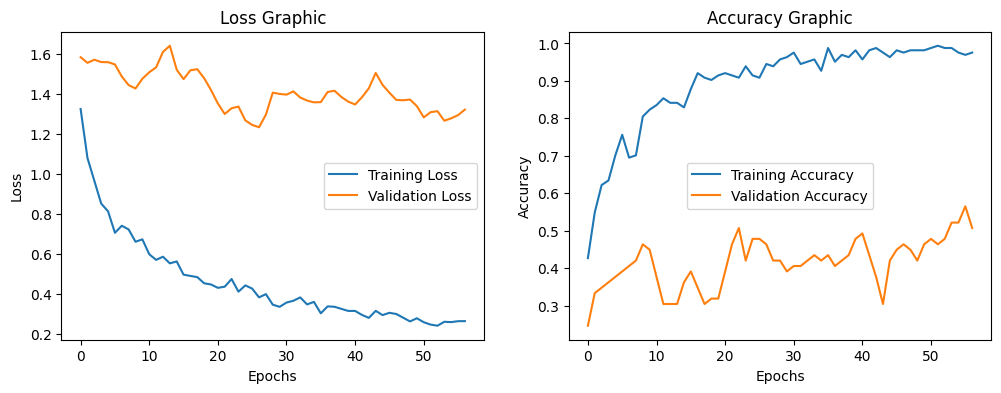

In [23]:
# Plotando o histórico de treinamento após o treinamento
os.makedirs(f"{results_dir}/final", exist_ok=True)
plot_training_history(history_fine_tunning, f"{results_dir}/final", "fine_tunning_oasis_training_history.png")

### PREDIÇÃO VALIDAÇÃO

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
              precision    recall  f1-score   support

           0       0.65      0.65      0.65        40
           1       0.28      0.22      0.24        23
           2       0.36      0.67      0.47         6

    accuracy                           0.51        69
   macro avg       0.43      0.51      0.45        69
weighted avg       0.50      0.51      0.50        69



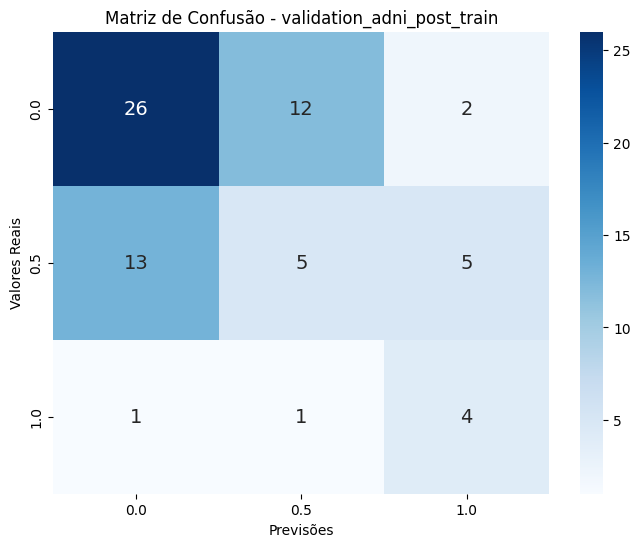

In [24]:
# Realizar predições para dados do conjunto validação
val_pred_labels_post_train, val_true_labels_post_train, val_pred_post_train = get_predictions(val_images_fine_tunning, val_labels_fine_tunning, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
get_classification_report(val_true_labels_post_train, val_pred_labels_post_train, f"{results_dir}/final", 'validation_adni_post_train')

# Obter matriz de confusão
plot_confusion_matrix(val_true_labels_post_train, val_pred_labels_post_train, f"{results_dir}/final", 'validation_adni_post_train', oasis_class_names)

# Criar pdf com predições
val_pdf_path_post_train = os.path.join(f"{results_dir}/final", "validation_adni_predictions_post_train.pdf")
create_pdf(val_paths_fine_tunning, val_images_fine_tunning, val_true_labels_post_train, val_pred_labels_post_train, val_pred_post_train, val_pdf_path_post_train, oasis_class_names)

### PREDIÇÃO TESTE

Passo 1: Coletando lista de arquivos...
Total de 227 imagens encontradas.
Passo 2: Determinando o shape da imagem...
Shape detectado: (156, 195, 160). Alocando memória para 227 imagens...
Passo 3: Carregando e transformando imagens...
Processado 50/227...
Processado 100/227...
Processado 150/227...
Processado 200/227...
Passo 4: Carregamento concluído.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 267ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 222ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 224ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step  
              precision    recall  f1-score   support

           0       0.33      1.00      0.50        73
           1       1.00      0.09      0.17        77
           2       0.00      0.00      0.00        77

    accuracy                           0.35       227
   macro avg       0.44      0.36      0.22       227
weighted avg       0.45      0.35      0.22       227



/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no

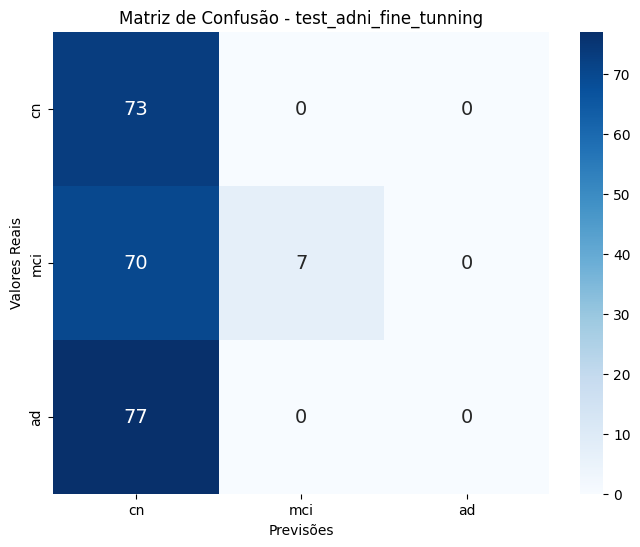

/tmp/ipykernel_719236/1130439845.py:289: RuntimeWarning: invalid value encountered in divide
  img = Image.fromarray(np.uint8(nifti_image / np.max(nifti_image) * 255))  # Normalizar e converter
/tmp/ipykernel_719236/1130439845.py:289: RuntimeWarning: invalid value encountered in cast
  img = Image.fromarray(np.uint8(nifti_image / np.max(nifti_image) * 255))  # Normalizar e converter


In [25]:
test_images_fine_tunning, test_labels_fine_tunning, test_paths_fine_tunning, _ = load_nifti_data_balanced_preallocated(test_dir, adni_class_names)

# Realizar predições para dados do conjunto validação
test_pred_labels_fine_tunning, test_true_labels_fine_tunning, test_pred = get_predictions(test_images_fine_tunning, test_labels_fine_tunning, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
get_classification_report(test_true_labels_fine_tunning, test_pred_labels_fine_tunning, f"{results_dir}/final", 'test_adni_fine_tunning')

# Obter matriz de confusão
plot_confusion_matrix(test_true_labels_fine_tunning, test_pred_labels_fine_tunning, f"{results_dir}/final", 'test_adni_fine_tunning', adni_class_names)

# Criar pdf com predições
test_pdf_path_fine_tunning = os.path.join(f"{results_dir}/final", "test_adni_predictions_fine_tunning.pdf")
create_pdf(test_paths_fine_tunning, test_images_fine_tunning, test_true_labels, test_pred_labels, test_pred, test_pdf_path, adni_class_names)

### PREDIÇÃO OASIS

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
              precision    recall  f1-score   support

           0       0.84      0.53      0.65        40
           1       0.38      0.43      0.41        23
           2       0.22      0.67      0.33         6

    accuracy                           0.51        69
   macro avg       0.48      0.54      0.46        69
weighted avg       0.63      0.51      0.54        69



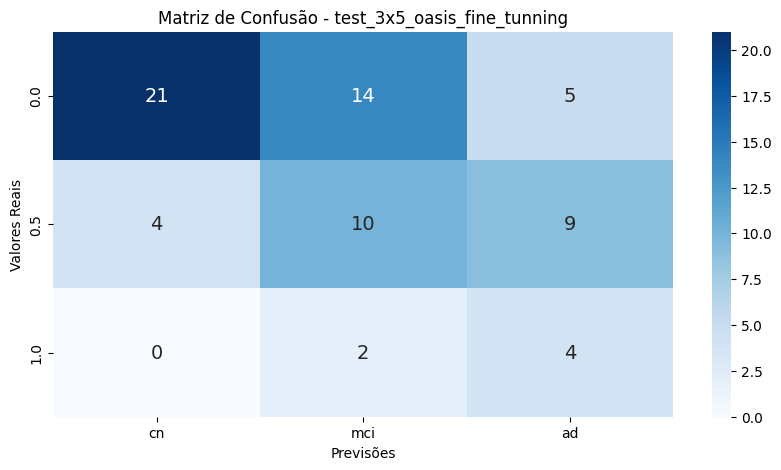

In [26]:
# Realizar predições para dados do conjunto validação
oasis_pred_labels, oasis_true_labels, oasis_pred = get_predictions(oasis_images, oasis_labels, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
get_classification_report(oasis_true_labels, oasis_pred_labels, f"{results_dir}/final", 'test_oasis_fine_tunning')

# Obter matriz de confusão
cm_adjusted = confusion_matrix(oasis_true_labels, oasis_pred_labels)
plot_custom_confusion_matrix(cm_adjusted, oasis_class_names, adni_class_names, f"{results_dir}/final", 'test_3x5_oasis_fine_tunning')

# # all_possible_numeric_labels = [0.0, 0.5, 1.0, 2.0, 3.0]

# cm_3x3_adjusted = confusion_matrix(oasis_true_labels, gathered_oasis_pred)[0:3, 0:3]

# # Chame a nova função para plotar a matriz ajustada (3x5)
# plot_custom_confusion_matrix(cm_3x3_adjusted, oasis_class_names, oasis_class_names, f"{results_dir}/final", 'test_3x3_oasis_fine_tunning')

# # Criar pdf com predições
oasis_pdf_path = os.path.join(f"{results_dir}/final", "test_oasis_predictions_fine_tunning.pdf")
# create_pdf(oasis_paths, oasis_images, oasis_true_labels, gathered_oasis_pred, oasis_pred, oasis_pdf_path, oasis_class_names)
create_pdf(oasis_paths, oasis_images, oasis_true_labels, oasis_true_labels, oasis_pred, oasis_pdf_path, oasis_class_names)